# Phase 2: Validation Against Real-World Clinical Data

## Stroke Risk Prediction — Real Dataset (Kaggle: Healthcare Dataset Stroke Data)

**Purpose of this notebook:** In Phase 1, we trained models on a synthetic dataset (`stroke_risk_dataset.csv`) and proved — through coefficient analysis, permutation importance, and hypothesis testing — that the near-perfect R² (0.999) was an artifact of the data generation formula, not a sign of a powerful model. The synthetic data gave every symptom roughly equal weight regardless of its real clinical significance.

This notebook applies the same rigor to a **real clinical dataset** to test whether:
1. The same modeling approach generalizes to real data.
2. Real clinical features (hypertension, heart disease, BMI, glucose) carry genuinely *different* weights, unlike the synthetic symptoms.
3. Performance metrics behave differently once real-world challenges (class imbalance, missing data) are involved.

## 1. Data Loading & First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
df.info()
print()
print("Duplicate rows:", df.duplicated().sum())
print("Unique patient ids:", df['id'].nunique(), "/", len(df))

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

Duplicate rows: 0
Unique patient ids: 5110 / 5110


## 2. Data Quality Check

### Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_summary[missing_summary["Missing Count"] > 0])

,Missing Count,Missing %
bmi,201,3.93


**Finding:** `bmi` has 201 missing values (3.9% of rows). This is a real-world data quality issue absent in the synthetic dataset, where every field was complete by construction. We'll address this with median imputation in the preprocessing step (Phase 2b), since BMI is right-skewed and the median is more robust to outliers than the mean.

### Categorical value checks (looking for inconsistent or rare categories)

In [4]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



**Finding:** `gender` has a single row labeled `"Other"` out of 5,110 — too sparse to model reliably as its own category. We'll flag this for the preprocessing step rather than silently dropping it here.

`smoking_status` has 1,544 rows labeled `"Unknown"` (30% of the data) — this is itself informative (missing-not-at-random) and will be kept as its own category rather than imputed, since treating "Unknown" as a real category is standard practice for this dataset and avoids fabricating smoking history.

## 3. Target Variable: Class Imbalance

This is the most important structural difference from the synthetic dataset. In Phase 1, the target was a continuous `Stroke Risk (%)` value with no imbalance issue. Here, `stroke` is a real binary outcome — and real stroke incidence in any population sample is rare.

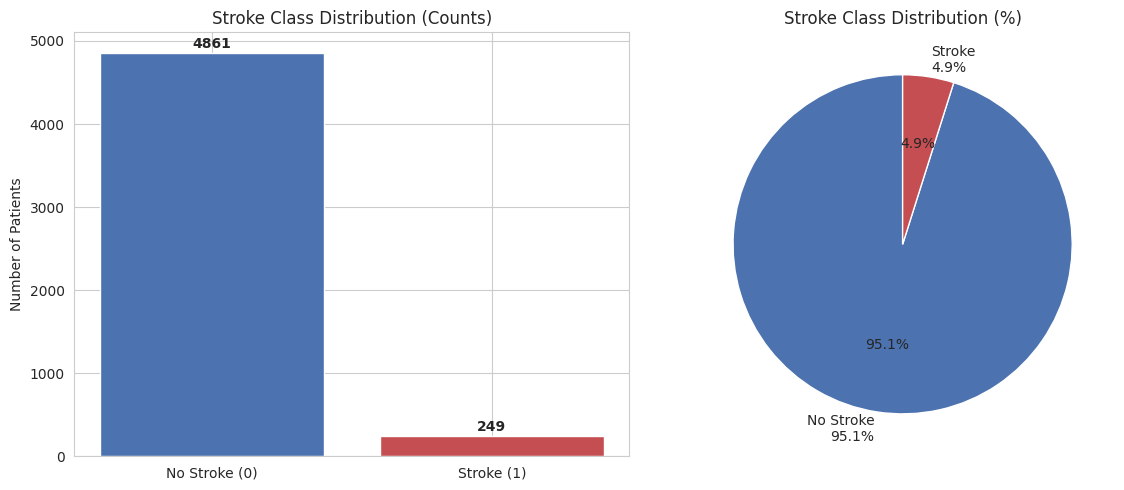


Only 249 out of 5110 patients (4.87%) had a stroke.
A model that always predicts 'No Stroke' would already achieve 95.13% accuracy
while being clinically useless (0% recall on the class that matters most).


In [5]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Stroke (0)', 'Stroke (1)'], stroke_counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Stroke Class Distribution (Counts)')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(stroke_pct.values, labels=[f'No Stroke\n{stroke_pct[0]:.1f}%', f'Stroke\n{stroke_pct[1]:.1f}%'],
            colors=['#4C72B0', '#C44E52'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Stroke Class Distribution (%)')

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nOnly {stroke_counts[1]} out of {len(df)} patients ({stroke_pct[1]:.2f}%) had a stroke.")
print(f"A model that always predicts 'No Stroke' would already achieve {stroke_pct[0]:.2f}% accuracy")
print("while being clinically useless (0% recall on the class that matters most).")

**Critical implication:** With only 4.87% positive cases, **accuracy is a misleading metric** for this problem. A naive model that always predicts "no stroke" scores ~95% accuracy while catching zero actual stroke cases. This is the opposite failure mode from Phase 1, where the synthetic data was too easy; here, the real challenge is that the signal we care about is rare and easy for a naive model to ignore.

We will prioritize **Recall** and **ROC-AUC** when evaluating models later in this notebook, consistent with the medical-safety-first approach in the original project brief (minimizing missed high-risk cases).

## 4. Numeric Feature Distributions

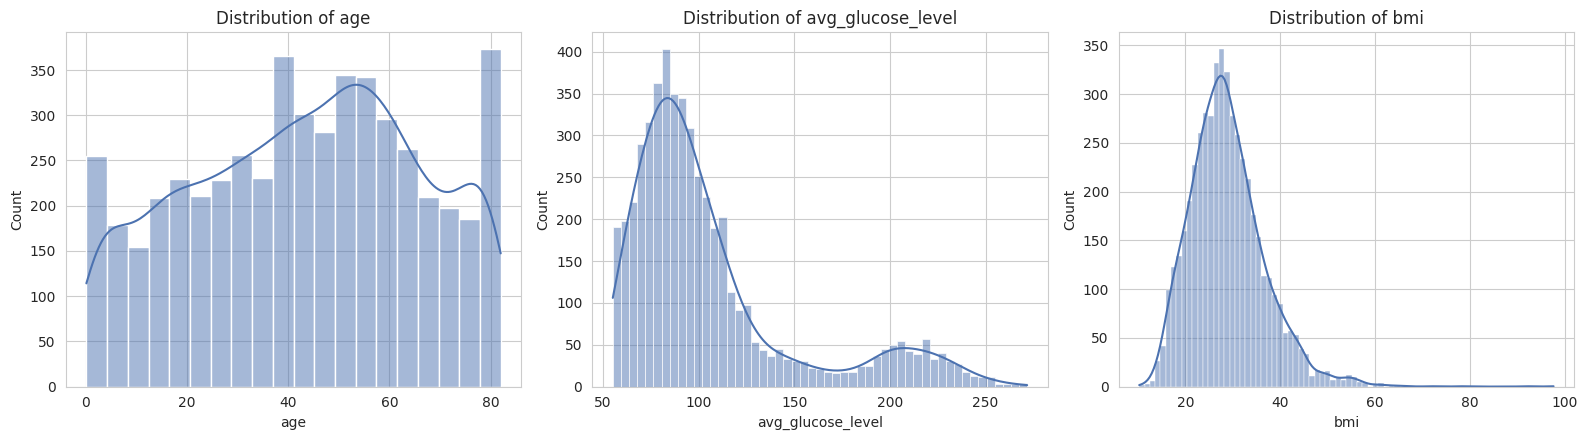

In [6]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

**Findings:**
- `age`: spans the full human lifespan (0.08 to 82 years), roughly uniform with a slight concentration in middle-to-older age — very different from the synthetic dataset's narrower simulated range.
- `avg_glucose_level`: right-skewed, with a long tail above 200 mg/dL (consistent with a subset of diabetic/pre-diabetic patients).
- `bmi`: roughly normal but right-skewed, with some extreme outliers (max 97.6, clinically very high — likely real but rare cases of severe obesity, not data errors).

## 5. Numeric Features vs Stroke (Does the real data show clinically expected patterns?)

/tmp/ipykernel_548/822845693.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_548/822845693.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Stroke', 'Stroke'])
/tmp/ipykernel_548/822845693.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_548/822845693.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Stro

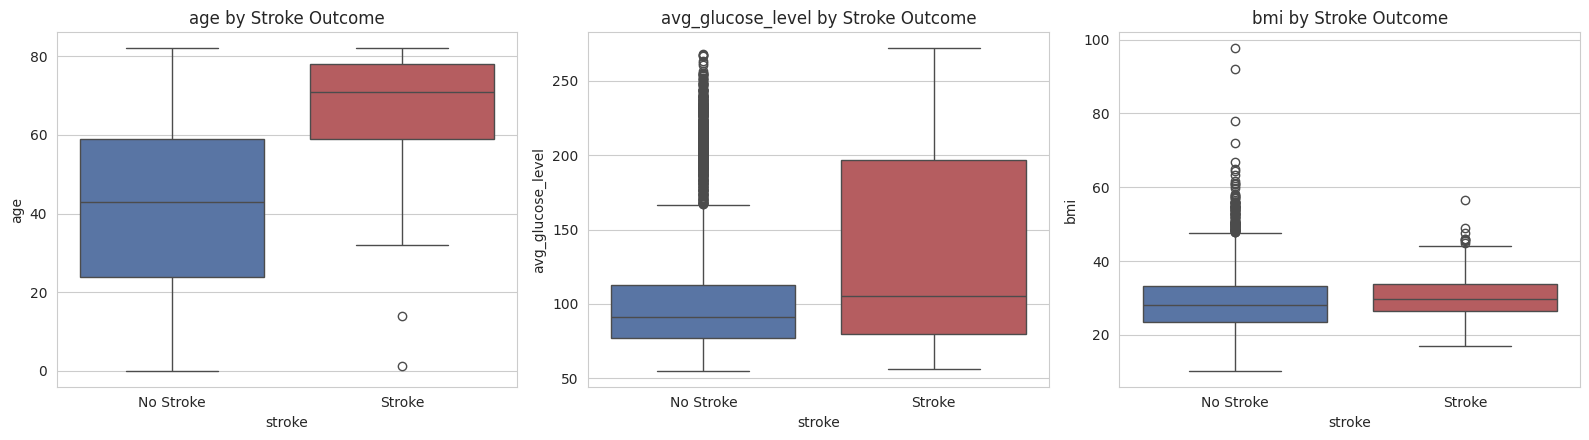

          age  avg_glucose_level    bmi
stroke                                 
0       41.97             104.80  28.82
1       67.73             132.54  30.47


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{col} by Stroke Outcome')
    ax.set_xticklabels(['No Stroke', 'Stroke'])
plt.tight_layout()
plt.savefig('numeric_vs_stroke.png', dpi=100, bbox_inches='tight')
plt.show()

print(df.groupby('stroke')[numeric_cols].mean().round(2))

**Finding:** Patients who had a stroke are visibly older on average and have somewhat higher glucose levels than those who didn't — a real, clinically expected pattern. This is fundamentally different from the synthetic dataset, where *every* symptom carried an almost identical weight by construction. Here we expect (and will verify in modeling) that **age dominates**, similar to Phase 1, but that other features like glucose and hypertension contribute meaningfully and *unequally* — which the synthetic data could never show.

## 6. Binary / Categorical Risk Factors vs Stroke

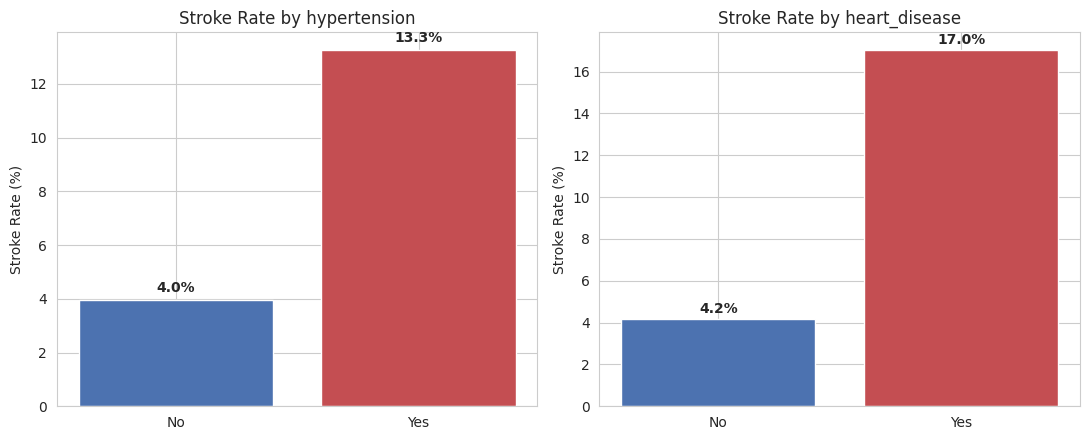

In [8]:
binary_cols = ['hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, binary_cols):
    rates = df.groupby(col)['stroke'].mean() * 100
    ax.bar(['No', 'Yes'], rates.values, color=['#4C72B0', '#C44E52'])
    ax.set_title(f'Stroke Rate by {col}')
    ax.set_ylabel('Stroke Rate (%)')
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('binary_risk_factors.png', dpi=100, bbox_inches='tight')
plt.show()

**Finding:** Stroke rate jumps from ~4% to ~13% with hypertension, and from ~4% to ~17% with heart disease. These are roughly **3–4x relative risk increases** — a real, clinically meaningful, and *unequal* effect size. Compare this to Phase 1, where every synthetic symptom shifted risk by an almost identical, fixed amount (~5 percentage points) regardless of which symptom it was. This is the core distinction we'll carry into the modeling comparison: real risk factors differ in strength; synthetic ones didn't.

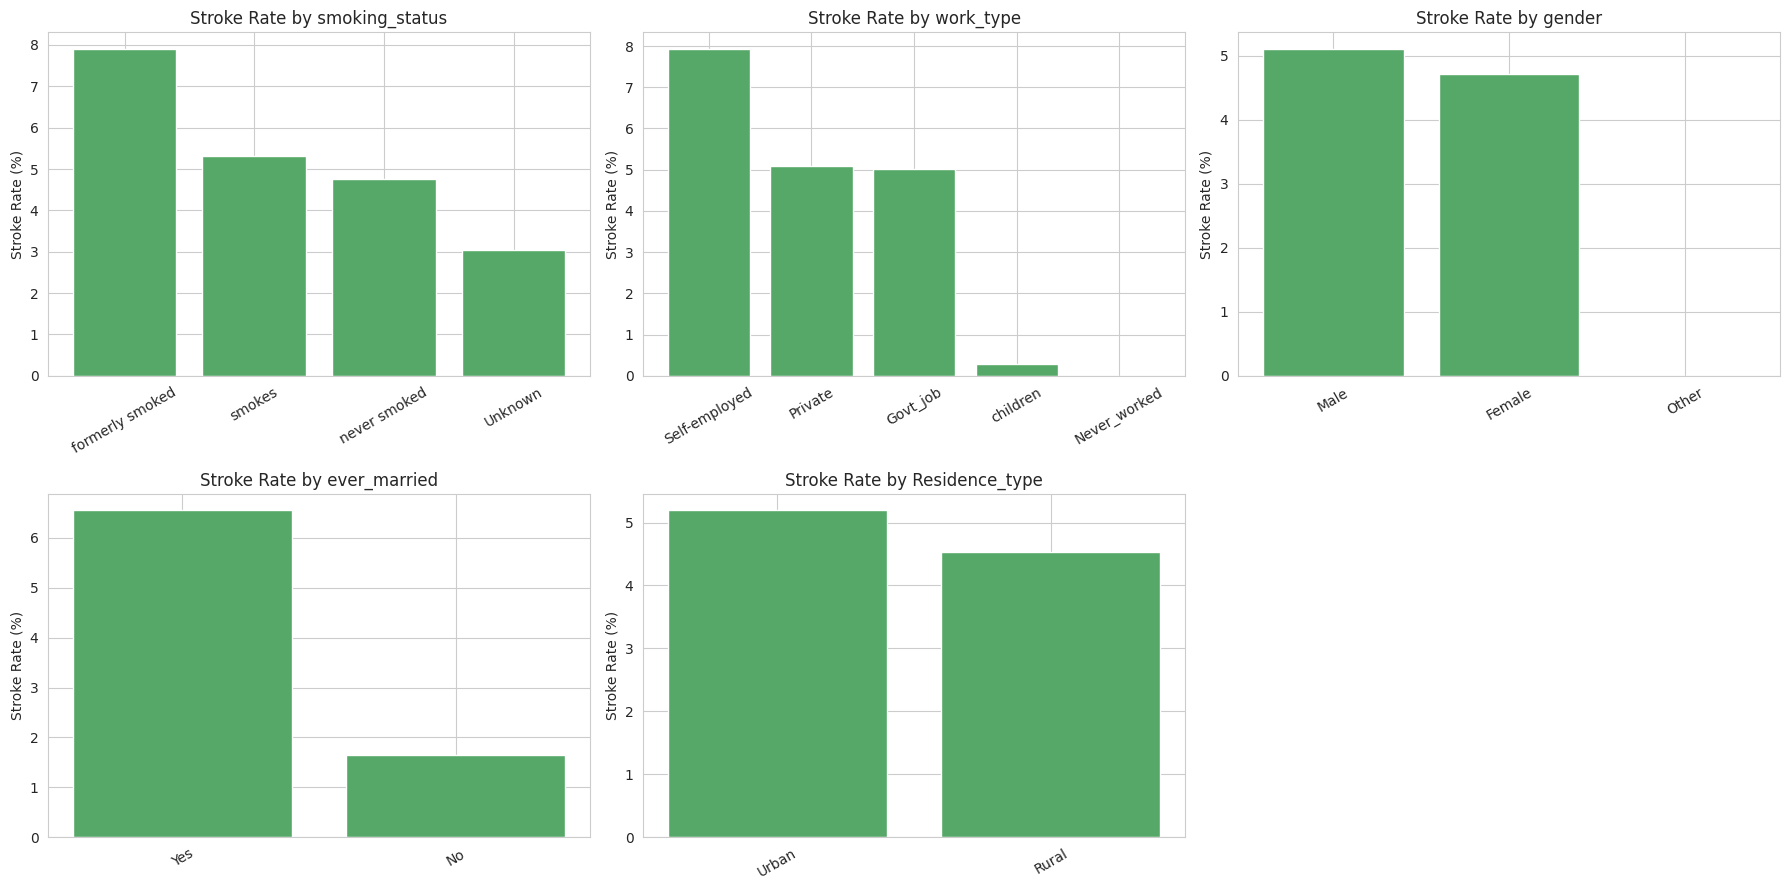

In [9]:
categorical_check_cols = ['smoking_status', 'work_type', 'gender', 'ever_married', 'Residence_type']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for ax, col in zip(axes, categorical_check_cols):
    rates = df.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    ax.bar(rates.index, rates.values, color='#55A868')
    ax.set_title(f'Stroke Rate by {col}')
    ax.set_ylabel('Stroke Rate (%)')
    ax.tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('categorical_risk_factors.png', dpi=100, bbox_inches='tight')
plt.show()

**Findings:**
- `smoking_status`: "formerly smoked" shows the highest stroke rate — plausible, since former smokers tend to be older and may have quit *after* a health scare (a known confound in this exact public dataset, frequently discussed in analyses of it).
- `work_type`: "Self-employed" shows a notably higher rate, again likely confounded with age (self-employment correlates with being older on average in this sample) rather than being a direct cause.
- `gender`, `ever_married`, `Residence_type`: show smaller differences — these look like weaker or more confounded predictors, unlike the uniformly-weighted symptoms in the synthetic data.

These confounding patterns (age driving apparent effects in other variables) are a genuine real-data complexity that the synthetic dataset, by construction, never had to deal with.

## 7. Correlation Overview (Numeric Features)

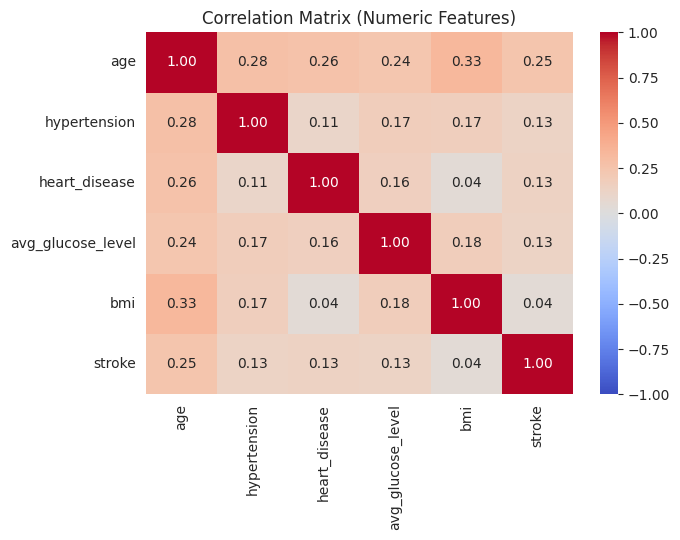

In [10]:
corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

**Finding:** `age` has by far the strongest correlation with `stroke` among numeric features, consistent with both clinical knowledge and the Phase 1 finding (where Age was also the single strongest predictor). However, unlike Phase 1, the *other* features here (hypertension, heart_disease, glucose, bmi) show clearly different — and weaker — correlation strengths with each other and with stroke, rather than the artificially uniform pattern seen in the synthetic symptoms.

## 8. EDA Summary

| Aspect | Synthetic Dataset (Phase 1) | Real Dataset (Phase 2, this notebook) |
|---|---|---|
| Rows | 70,000 | 5,110 |
| Target | Continuous `Stroke Risk (%)` | Binary `stroke` (0/1) |
| Class balance | N/A (regression) | **Severely imbalanced: 4.87% positive** |
| Missing data | None | 201 missing `bmi` values (3.9%) |
| Feature weighting | All 15 symptoms ≈ equal weight (by construction) | Risk factors show clearly **unequal**, clinically plausible effect sizes (hypertension +3x, heart disease +4x relative risk) |
| Confounding | None (features generated independently) | Present (e.g., work_type and smoking_status effects appear confounded with age) |
| Data quality issues | None | Rare category (`gender = "Other"`, n=1), `Unknown` smoking status (30%) |

**Conclusion of EDA:** This real dataset presents fundamentally different challenges than the synthetic one: severe class imbalance, missing data, and confounded categorical effects. Unlike Phase 1, where the modeling challenge was almost nonexistent (the data was too clean), the modeling challenge here is genuine. The next notebook section (Phase 2b) will cover preprocessing and classification modeling, with metrics chosen specifically to handle the imbalance problem identified here.